In [13]:
import argparse
import corner
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import time
import yaml


import numcosmo_I as nc

from datetime import datetime
from pathlib import Path

## Data and Config

In [14]:
def extraction(config_dict):
    
    sne_path = config_dict[ "data_supernovae" ]
    cov_path = config_dict[ "data_cov" ]
    
    print( f"Loading data from: {sne_path}" )
    print( f"Loading covariance from: {cov_path}" )
          
    z, mu_obs, mu_err = np.loadtxt( sne_path, usecols = (1, 2, 3), unpack = True )
    covariance_data   = np.loadtxt(cov_path)

    assert len( z )              == 580, f"Expected 580 SNe, got {len( z )}"
    assert covariance_data.shape == ( len( z ), len( z ) ), "Covariance matrix shape incompatible with N_SNe"

    print( "Data obtained: z, mu_obs, mu_err" )
    print( f"SNe loaded: {len( z )}" )
    print( f"Covariance shape: {covariance_data.shape}" )
    
    return z, mu_obs, mu_err, covariance_data

In [15]:
LATEX_LABELS = {
    "Omega_m":                r"$\Omega_m$",
    "cosmology.Omega_m":      r"$\Omega_m$",
    "Omega_lambda":           r"$\Omega_\Lambda$",
    "cosmology.Omega_lambda": r"$\Omega_\Lambda$",
    "M_abs":                  r"$M_{\rm abs}$",
    "cosmology.M_abs":        r"$M_{\rm abs}$",
    "h":                      r"$h$",
    "cosmology.h":            r"$h$",
    "w0_fld":                 r"$w_0$",
    "cosmology.w0_fld":       r"$w_0$",
    "wa_fld":                 r"$w_a$",
    "cosmology.wa_fld":       r"$w_a$",
}

def get_latex_labels(param_names):
     return [ LATEX_LABELS.get( p, p.replace( "_", r"\_" ) ) for p in param_names ]


In [16]:
yaml_path = '/home/alex/Área de trabalho/Pós-Graduação/Disciplinas/Numerical_Cosmology_1/EP_I/config/Supernovae_setup.yaml'

print( 100 * "=" )
print( "Loading Initial Setup" )
print( 100 * "=" + "\n" )

with open(yaml_path, "r", encoding = "utf-8" ) as config_file:
    config = yaml.safe_load( config_file )

print(f"{yaml.dump( config, sort_keys = False, allow_unicode = True ) }")

config_cosmo = config[ "cosmology" ]
config_exp   = config[ "experiment_config" ]
config_param = config[ "parameters" ]
config_out   = config[ "output" ]

os.makedirs( config_out[ "root" ], exist_ok = True )


timestamp     = datetime.now().strftime( "%Y%m%d_%H%M%S" )
base_filename = f"{config_out[ 'base_name' ]}_{timestamp}"
output_base   = os.path.join( config_out[ "root" ], base_filename)

print( 100 * "=" )
print( f"Output base set as: {output_base}" )
    
print( 100 * "=" )
print( "Starting data Extraction" )
    
    
z, mu_obs, mu_err, covariance_data = extraction( config_exp )

print( 100 * "=" )
print("Extraction ran Successfully")
print( 100 * "=" + "\n" )

Loading Initial Setup

cosmology:
  h: 0.6737
  Omega_r: 0.0
  Omega_m: 0.315
  Omega_lambda: 0.685
  w0_fld: -1.0
  wa_fld: 0.0
experiment_config:
  data_supernovae: /home/alex/Área de trabalho/Pós-Graduação/Disciplinas/Numerical_Cosmology_1/EP_I/data/SCPUnion2.1_mu_vs_z.txt
  data_cov: /home/alex/Área de trabalho/Pós-Graduação/Disciplinas/Numerical_Cosmology_1/EP_I/data/SCPUnion2.1_covmat_sys.txt
  seed: 5485
  nalive: 500
  max_steps: 50000
  ratio_conv: 0.0001
  acceptance: 0.3
  n_itx: 10
  dump_lenght: 100
  outfile_flag: true
  resume_flag: true
  burn_in_fraction: 0.4
parameters:
  cosmology.Omega_m:
    prior:
      min: 0.0
      max: 2.0
  cosmology.Omega_lambda:
    prior:
      min: -1.0
      max: 3.0
  cosmology.M_abs:
    prior:
      min: -1.0
      max: 1.0
output:
  root: /home/alex/Área de trabalho/Pós-Graduação/Disciplinas/Numerical_Cosmology_1/EP_I/examples_and_analysis/output
  base_name: Union2.1
  write_output: true
  headers: true

Output base set as: /home/al

## Cosmology 

In [17]:
model = nc.cosmology.FLRW(
        h            = config_cosmo[ "h" ],
        Omega_m      = config_cosmo[ "Omega_m" ],
        Omega_lambda = config_cosmo[ "Omega_lambda" ],
        Omega_r      = config_cosmo[ "Omega_r" ],
        w0_fld       = config_cosmo[ "w0_fld" ],
        wa_fld       = config_cosmo[ "wa_fld" ],
    )

sort_idx = np.argsort(z)
z_sorted = z[sort_idx]

plot_distances = {
        "Luminosity Distance":          model.luminosity_distance( z_sorted ),
        "Angular Distance":             model.angular_diameter_distance( z_sorted ),
        "Radial Comoving Distance":     model.comoving_distance( z_sorted ),
        "Transverse Comoving Distance": model.transverse_comoving_distance( z_sorted ),
    }


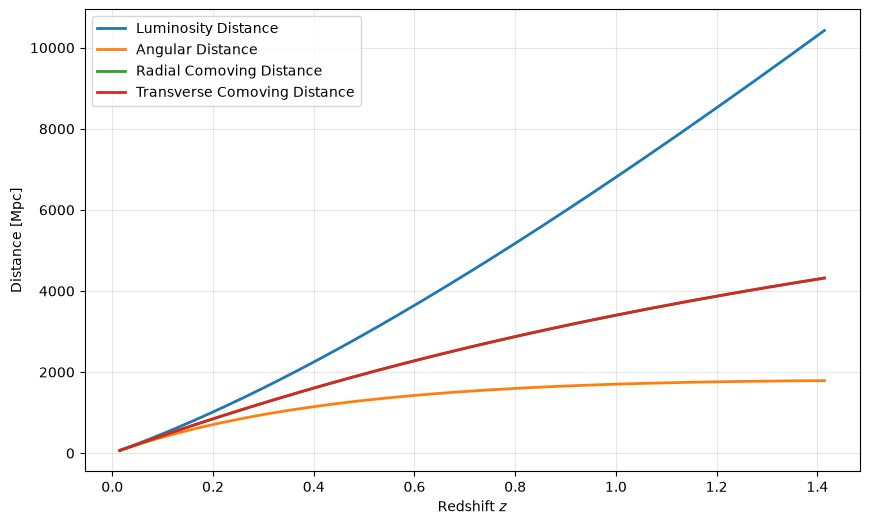

Distances plot saved to: /home/alex/Área de trabalho/Pós-Graduação/Disciplinas/Numerical_Cosmology_1/EP_I/examples_and_analysis/output/Union2.1_20260909_162104_distances.png



In [18]:
plt.figure( figsize = ( 10, 6 ) )
for case, dist in plot_distances.items():
    plt.plot( z_sorted, dist, label = case, lw = 2 )

plt.xlabel( r"Redshift $z$" )
plt.ylabel( "Distance [Mpc]" )
plt.legend()
plt.grid( True, alpha = 0.3 )
    
distances_plot_path = f"{output_base}_distances.png"
plt.savefig( distances_plot_path, dpi = 300, bbox_inches = "tight" )
#plt.close()
plt.show()
print( f"Distances plot saved to: {distances_plot_path}\n" )

## Sampling


In [20]:
param_names, bounds = nc.likelihoods.parser_yaml_priors( config_param )

like = nc.likelihoods.LikelihoodSupernovae(
            z_obs       = z, 
            mu_obs      = mu_obs,
            cov_matrix  = covariance_data, 
            param_names = param_names,
            defaults    = config_cosmo
    )
    
priors_transf = lambda u: like.prior_transform( u, bounds, param_names )
    
sampler = nc.samplers.NestedSampler(
            log_likelihood_fn  = like.log_likelihood,
            prior_transform_fn = priors_transf,
            ndim               = len( param_names ),
            nlive              = config_exp[ "nalive" ],
            dlogz              = config_exp[ "ratio_conv" ],
            max_steps          = config_exp[ "max_steps" ],
            target_acceptance  = config_exp[ "acceptance" ],
            num_itx            = config_exp[ "n_itx" ],
            seed               = config_exp[ "seed" ],
    )
    
run_results = sampler.run(   
            resume_flag     = True, 
            checkpoint_file = f"{output_base}.resume", 
            dump_length = config_exp[ "dump_lenght" ] 
    )

    
results_file = f"{output_base}_results.dat"
with open( results_file, "wb" ) as f:
    pickle.dump( run_results, f )
print( f"\nSampling results saved to: {results_file}" )

->  Starting new Nested Sampling run ...

   Step |       logZ |      dlogZ |    L_worst |  Step Size |    Acc Rate
      1 |       -inf |        inf |       -inf |     0.1000 |      30.00%
    100 |  -1527.475 | 1250.00650 |  -1521.061 |     0.4050 |      50.00%
    200 |   -964.555 |  689.93213 |   -957.943 |     0.3165 |      30.00%
    300 |   -785.802 |  510.97855 |   -779.252 |     0.3037 |       0.00%
    400 |   -640.594 |  365.57051 |   -633.818 |     0.2768 |      10.00%
    500 |   -549.144 |  273.92060 |   -542.179 |     0.2385 |      10.00%
    600 |   -487.760 |  212.33683 |   -481.861 |     0.2517 |      40.00%
    700 |   -449.983 |  174.35962 |   -443.721 |     0.2289 |       0.00%
    800 |   -423.781 |  147.95807 |   -417.420 |     0.1972 |      20.00%
    900 |   -405.210 |  129.26114 |   -399.125 |     0.1784 |      40.00%
   1000 |   -384.523 |  108.37394 |   -378.522 |     0.1468 |      10.00%
   1100 |   -370.779 |   94.43028 |   -364.367 |     0.1482 |      20.

## Post Processing & output

In [22]:
print( "\n" + 100 * "=" )
print( "Processing Diagnostics and Output Files" )
print( 100 * "="  )

samples   = run_results[ "samples" ]
weights   = run_results.get("weights")
log_likes = run_results[ "log_likelihoods" ]
logZ      = run_results[ "logZ" ]


burn_in_frac = config_exp.get( "burn_in_fraction" , 0.0)
    
if burn_in_frac   > 1.0:
    burn_in_frac /= 100.0

cut_index = int( len( samples ) * burn_in_frac )

samples_burned   = samples[ cut_index: ]
log_likes_burned = log_likes[ cut_index: ]
weights_burned   = weights[ cut_index: ] if weights is not None else None

print( f"Burn-in successfully applied | Removed: {cut_index}/{len(samples)} samples" )    


Processing Diagnostics and Output Files
Burn-in successfully applied | Removed: 3682/9206 samples


In [34]:
best_log_like = np.max( log_likes_burned )
chi2_info = nc.diagnostics.compute_reduced_chi2(
    best_fit_log_like = best_log_like,
    n_data            = len( z ),
    n_params          = len( param_names) ,
)

print( "\nGoodness-of-Fit Summary:" )
print( f"  Best-fit log-likelihood: {best_log_like:.4f}" )
print( f"  Chi-squared (chi2):       {chi2_info[ 'chi2' ]:.4f}" )
print( f"  Degrees of Freedom (dof): {chi2_info[ 'dof' ]}" )
print( f"  Reduced chi2 (chi2/dof):  {chi2_info[ 'chi2_red' ]:.4f}" )


Goodness-of-Fit Summary:
  Best-fit log-likelihood: -272.5547
  Chi-squared (chi2):       545.1093
  Degrees of Freedom (dof): 577
  Reduced chi2 (chi2/dof):  0.9447


In [29]:
ess = nc.diagnostics.compute_ess(samples_burned)
mcse = nc.diagnostics.compute_mcse(samples_burned, ess)
dunkley = nc.diagnostics.dunkley_power_spectrum(samples_burned)

chains_3d = (
        samples_burned[np.newaxis, :, :]
        if samples_burned.ndim == 2
        else samples_burned
    )
split_rhat = nc.diagnostics.compute_split_rhat(chains_3d)

stats   = nc.diagnostics.compute_stats(
        samples_burned, 
        weights_burned, 
        param_names
    )
ns_diag = nc.diagnostics.compute_nested_sampling_diagnostics(
        log_likes_burned, 
        weights_burned, 
        logZ, 
        nlive = config_exp[ "nalive" ]
    )

In [33]:
print("\nPosterior Parameters & Convergence Summary:")
print( f"{'Parameter':>15s} | {'Mean':>8s} +/- {'Std':>8s} | {'Median':>8s} | {'ESS':>7s} | {'MCSE':>9s} | {'R-hat':>7s} | Dunkley"
    )
print("-" * 92)
for i, p in enumerate( param_names ):
    s           = stats[ p ]
    dunk_passed = dunkley.get( f"param_{i}", {} ).get( "passed", False )
    dunk_str    = "PASS" if dunk_passed else "FAIL"
    print( f"{p:>15s} | {s['mean']:8.4f} +/- {s['std']:8.4f} | {s['median']:8.4f} | "
           f"{ess[i]:7.1f} | {mcse[i]:9.4e} | {split_rhat[i]:7.4f} | {dunk_str}" )

print( f"\n  log(Z): {logZ:.3f} +/- {ns_diag.get( 'logZ_err', 0.0 ):.3f}")
print( f"  Shannon Information (H): {ns_diag.get( 'shannon_information', np.nan ):.3f} nats\n" )


Posterior Parameters & Convergence Summary:
      Parameter |     Mean +/-      Std |   Median |     ESS |      MCSE |   R-hat | Dunkley
--------------------------------------------------------------------------------------------
        Omega_m |   0.2767 +/-   0.0907 |   0.2767 |  3721.8 | 8.2173e-04 |  1.0100 | PASS
   Omega_lambda |   0.6631 +/-   0.1672 |   0.6607 |  3897.4 | 1.4897e-03 |  1.0136 | PASS
          M_abs |  -0.0698 +/-   0.0265 |  -0.0701 |  4878.0 | 2.1019e-04 |  1.0029 | PASS

  log(Z): -280.756 +/- 0.120
  Shannon Information (H): 7.243 nats



##  Plots

Corner plot saved to: /home/alex/Área de trabalho/Pós-Graduação/Disciplinas/Numerical_Cosmology_1/EP_I/examples_and_analysis/output/Union2.1_20260909_162104_corner_plot.png


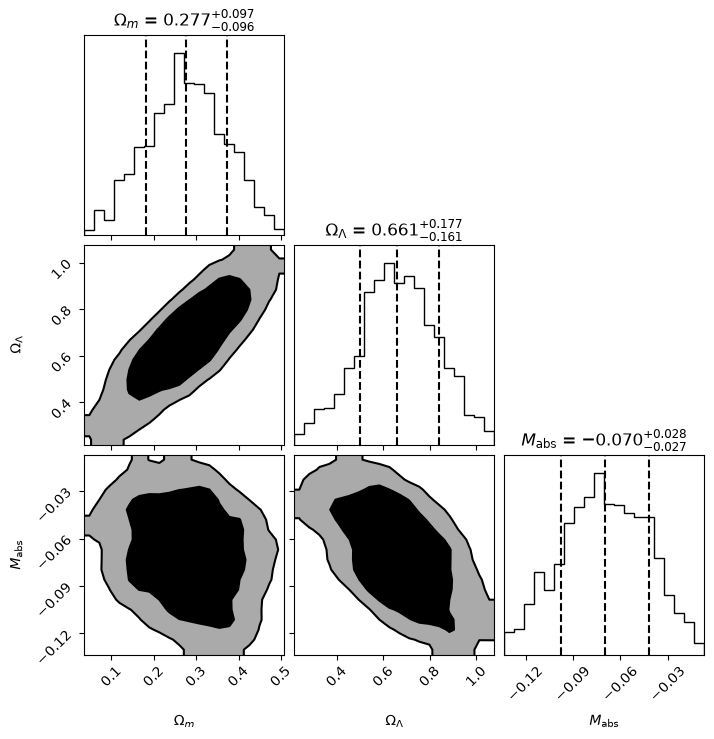

In [36]:
latex_param_names = get_latex_labels(param_names)

corner_path = f"{output_base}_corner_plot.png"

nc.diagnostics.plot_corner(
        samples_burned,
        weights=weights_burned,
        param_names=latex_param_names,
        save_path=corner_path,
)
print(f"Corner plot saved to: {corner_path}")

Trace plot saved to: /home/alex/Área de trabalho/Pós-Graduação/Disciplinas/Numerical_Cosmology_1/EP_I/examples_and_analysis/output/Union2.1_20260909_162104_traces.png


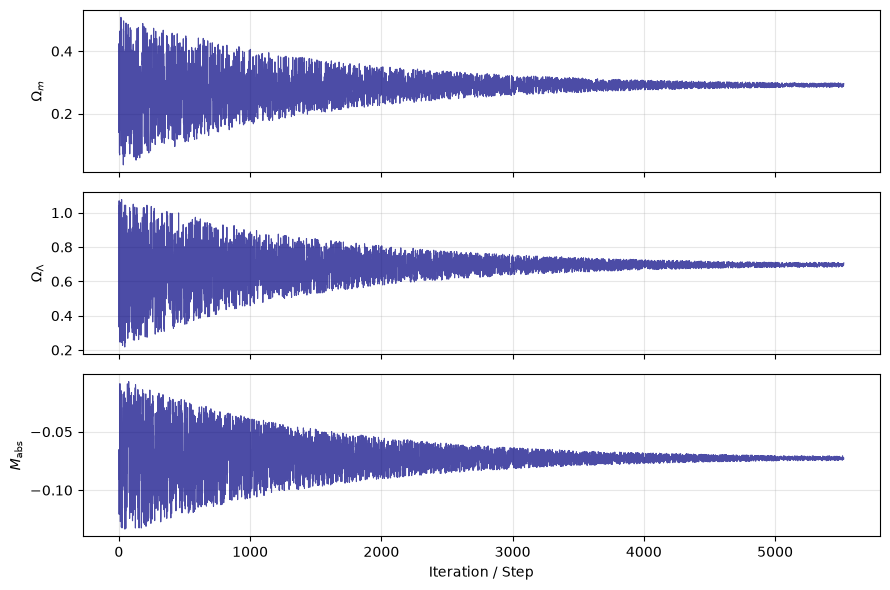

In [37]:
traces_path = f"{output_base}_traces.png"

nc.diagnostics.plot_traces(
        samples_burned,
        param_names=latex_param_names,
        save_path=traces_path,
)
print(f"Trace plot saved to: {traces_path}")

Hubble diagram saved to: /home/alex/Área de trabalho/Pós-Graduação/Disciplinas/Numerical_Cosmology_1/EP_I/examples_and_analysis/output/Union2.1_20260909_162104_hubble_plot.png


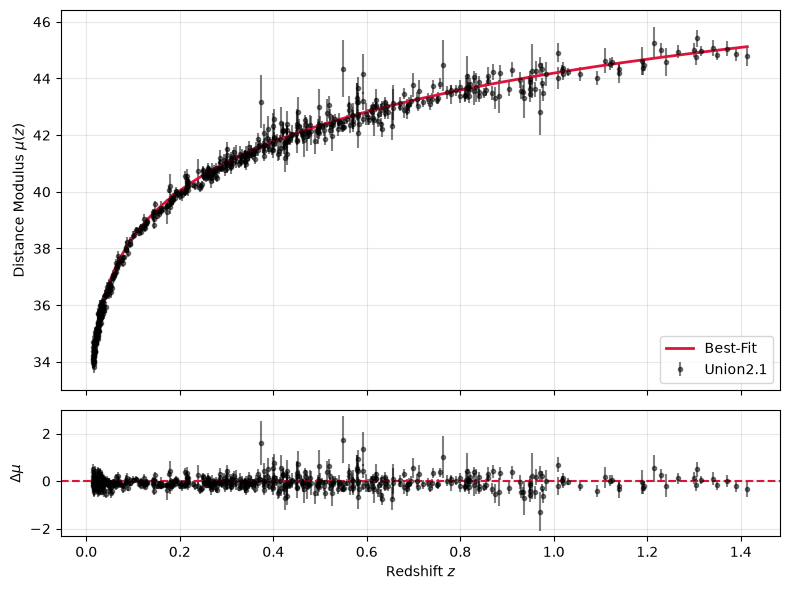

In [39]:
best_idx    = np.argmax( log_likes_burned )
best_params = samples_burned[ best_idx ]
best_dict   = dict( zip( param_names, best_params ) )

flrw_valid_keys = {
        "h",
        "Omega_m",
        "Omega_lambda",
        "Omega_r",
        "w0_fld",
        "wa_fld",
}
full_cosmo = config_cosmo.copy()

for p_name, val in best_dict.items():
        clean_key = p_name.split( "." )[ -1 ]
        if clean_key in flrw_valid_keys:
            full_cosmo[ clean_key ] = val

best_model = nc.cosmology.FLRW( **full_cosmo )
mu_model   = best_model.distance_modulus( z_sorted )

hubble_path = f"{output_base}_hubble_plot.png"
nc.diagnostics.plot_hubble_diagram(
        z_sorted,
        mu_obs[ sort_idx ],
        mu_err[ sort_idx ],
        mu_model,
        save_path = hubble_path,
    )
print(f"Hubble diagram saved to: {hubble_path}")